In [7]:
import os
import pickle
import re
import gc
from pathlib import Path

import pandas as pd
import numpy as np
from utils.model_saver import *


def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data').exists() and (candidate / 'Models').exists() and (candidate / 'notebooks').exists():
            return candidate
    return current


PROJECT_ROOT = find_project_root()
print(f"Project root: {PROJECT_ROOT}")

PATH_DATA = PROJECT_ROOT / 'data'
PATH_NORMAL_DATA = PATH_DATA / 'initial_features'
PATH_GRAPH_DATA = PATH_DATA / 'graph_features'
PATH_TEXT_DATA = PATH_DATA / 'textual_features'
PATH_COMBINED_DATA = PATH_DATA / 'combined_features'
MODELS_SAVE_PATH = PROJECT_ROOT / 'Models'

SAVE = True
PATH_PLOTS = PROJECT_ROOT / 'report' / 'src'
TARGET = 'is_reference_valid'
RANDOM_STATE = 42

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# Keep prediction memory use predictable.
N_JOBS = 1


Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Using device: cuda


In [8]:
import gc
import pandas as pd

from sklearn.preprocessing import RobustScaler


ID_COLUMNS = ["article_id", "ref_id"]
TARGET_COL = "is_reference_valid"
RANDOM_STATE = 42


def load_scale_sample(
    train_path,
    test_path=None,
    sample_size=20_000,
    target_col=TARGET_COL,
    id_columns=ID_COLUMNS,
    split_col="split",
    random_state=RANDOM_STATE,
):
    # Case 1: train/test are in two separate files
    if test_path is not None:
        train = pd.read_parquet(train_path)
        test = pd.read_parquet(test_path)

    # Case 2: train/test are in one file with split column
    else:
        df = pd.read_parquet(train_path)
        split = df[split_col].astype(str).str.lower()
        train = df[split == "train"].copy()
        test = df[split == "test"].copy()
        del df, split
        gc.collect()

    train = train.drop(columns=list(id_columns) + [split_col], errors="ignore")
    test = test.drop(columns=list(id_columns) + [split_col], errors="ignore")

    y_train = train[target_col].copy()
    y_test = test[target_col].copy()

    X_train = train.drop(columns=[target_col])
    X_test = test.drop(columns=[target_col])

    num_cols = X_train.select_dtypes(include="number").columns

    scaler = RobustScaler()

    train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train[num_cols]),
        columns=num_cols,
        index=X_train.index,
    )

    test_scaled = pd.DataFrame(
        scaler.transform(X_test[num_cols]),
        columns=num_cols,
        index=X_test.index,
    )

    train_scaled[target_col] = y_train.values
    test_scaled[target_col] = y_test.values

    del train, test, X_train, X_test, y_train, y_test
    gc.collect()

    train_scaled = train_scaled.sample(
        n=min(sample_size, len(train_scaled)),
        random_state=random_state,
    ).reset_index(drop=True)

    test_scaled = test_scaled.sample(
        n=min(sample_size, len(test_scaled)),
        random_state=random_state,
    ).reset_index(drop=True)

    gc.collect()

    return train_scaled, test_scaled, scaler

In [9]:
ID_COLUMNS = ["article_id", "ref_id"]
NON_FEATURE_COLUMNS = ID_COLUMNS + ["split"]

norm_train, norm_test, norm_scaler = load_scale_sample(
    PATH_NORMAL_DATA / "train.parquet",
    PATH_NORMAL_DATA / "test.parquet",
)

graph_train, graph_test, graph_scaler = load_scale_sample(
    PATH_GRAPH_DATA / "train.parquet",
    PATH_GRAPH_DATA / "test.parquet",
)

text64_train, text64_test, text64_scaler = load_scale_sample(
    PATH_TEXT_DATA / "textual_embeddings_64.parquet",
    test_path=None, sample_size=2_000 
)

text128_train, text128_test, text128_scaler = load_scale_sample(
    PATH_TEXT_DATA / "textual_embeddings_128.parquet",
    test_path=None, sample_size=2_000
)

mix_train, mix_test, mix_scaler = load_scale_sample(
    PATH_COMBINED_DATA / "train.parquet",
    PATH_COMBINED_DATA / "test.parquet",
    sample_size=2000
)

In [ ]:
from utils.comparison import *

# Models Comparison


## 1. Import Pretrained Models

In [11]:
# Usage
models_dict = load_latest_models(MODELS_SAVE_PATH)

# Helper function to safely get models
def get_model_safe(models_dict, folder, model_type):
    """Safely get a model, returning None if not available"""
    if folder in models_dict and model_type in models_dict[folder]:
        return models_dict[folder][model_type]
    print(f"⚠️  Warning: {model_type} not found in {folder}")
    return None

# Initial Features (only KNN available)
initial_feat_knn = get_model_safe(models_dict, 'initial_features', 'KNN')
initial_feat_xgb = get_model_safe(models_dict, 'initial_features', 'XGB')
initial_feat_transformer = get_model_safe(models_dict, 'initial_features', 'transformer')

# Graph Features
graph_feat_knn = get_model_safe(models_dict, 'graph_features', 'KNN')
graph_feat_xgb = get_model_safe(models_dict, 'graph_features', 'XGB')
graph_feat_transformer = get_model_safe(models_dict, 'graph_features', 'transformer')

# Textual 64
text64_feat_knn = get_model_safe(models_dict, 'textual_embeddings_64', 'KNN')
text64_feat_xgb = get_model_safe(models_dict, 'textual_embeddings_64', 'XGB')
text64_feat_transformer = get_model_safe(models_dict, 'textual_embeddings_64', 'transformer')

# Textual 128
text128_feat_knn = get_model_safe(models_dict, 'textual_embeddings_128', 'KNN')
text128_feat_xgb = get_model_safe(models_dict, 'textual_embeddings_128', 'XGB')
text128_feat_transformer = get_model_safe(models_dict, 'textual_embeddings_128', 'transformer')

# All Features
all_feat_knn = get_model_safe(models_dict, 'combined_features', 'KNN')
all_feat_xgb = get_model_safe(models_dict, 'combined_features', 'XGB')
all_feat_transformer = get_model_safe(models_dict, 'combined_features', 'transformer')

comparison_metrics = {}
comparison_figure_paths = {}


Loaded transformer from exploded_splits: Transformer_diff_concept_20260502_161219.pkl
Loaded KNN from initial_features: Best_KNN_initial_based_20260503_235716.pkl
Loaded XGB from initial_features: Best_XGB_initial_based_20260504_104515.pkl
Loaded transformer from initial_features: Transformer_initial_based_20260504_112128.pkl
Loaded KNN from textual_embeddings_64: Best_KNN_textual_64_20260430_132326.pkl
Loaded XGB from textual_embeddings_64: Best_XGB_textual_64_20260430_144945.pkl
Loaded transformer from textual_embeddings_64: Best_Transformer_textual_64_20260504_110610.pkl
Loaded KNN from graph_features: Best_KNN_graph_based_20260502_190500.pkl
Loaded XGB from graph_features: Best_XGB_graph_20260430_152157.pkl
Loaded transformer from graph_features: Transformer_graph_20260430_164512.pkl
Loaded KNN from textual_embeddings_128: Best_KNN_textual_128_20260430_134647.pkl
Loaded XGB from textual_embeddings_128: Best_XGB_textual_128_20260430_152616.pkl
Loaded transformer from textual_embeddi

## 2. Comparison by feature types

### 2.1 Initial Features

/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [11:59:37] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This w

predict:   0%|          | 0/40 [00:00<?, ?it/s]

predict:   0%|          | 0/40 [00:00<?, ?it/s]

Saved figure: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/report/src/eval_models_normal.png


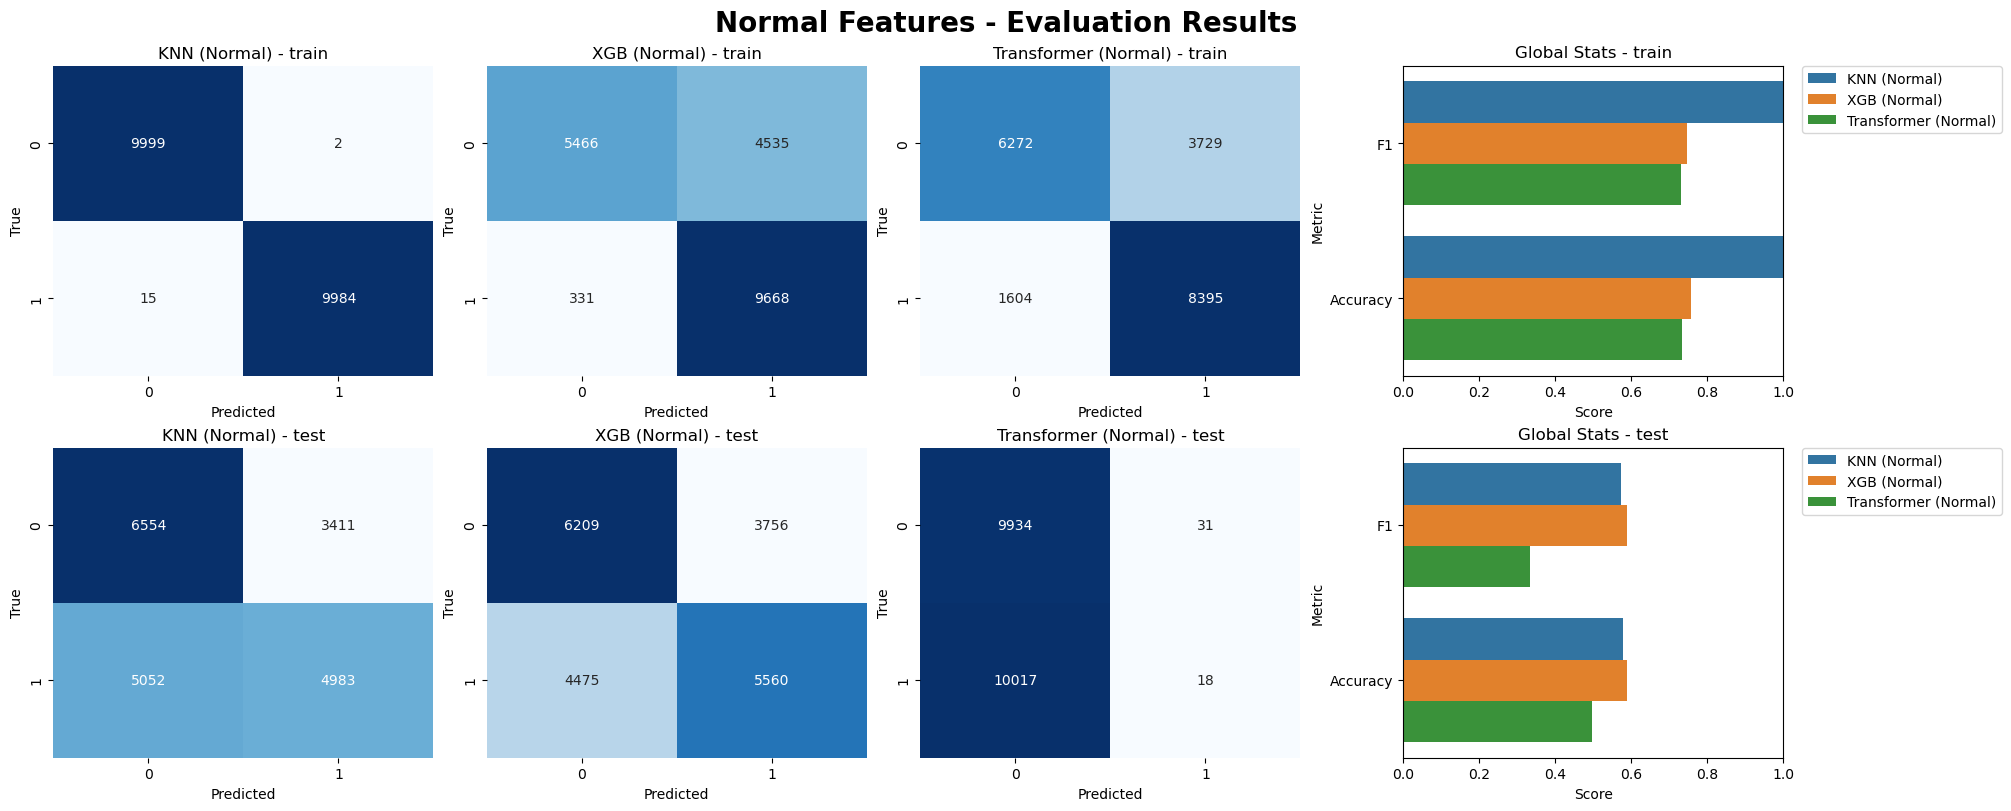

In [ ]:
sets_for_normal = set_dict(datasets=[norm_train, norm_test], names=['train', 'test'], id_columns=ID_COLUMNS)

initial_feat_models = [m for m in [initial_feat_knn, initial_feat_xgb, initial_feat_transformer] if m is not None]
initial_feat_models_names = []
if initial_feat_knn is not None:
    initial_feat_models_names.append('KNN (Normal)')
if initial_feat_xgb is not None:
    initial_feat_models_names.append('XGB (Normal)')
if initial_feat_transformer is not None:
    initial_feat_models_names.append('Transformer (Normal)')

if initial_feat_models:
    initial_feat_fig, initial_feat_metrics = plot_model_comparison(
        model_list=initial_feat_models,
        model_names=initial_feat_models_names,
        all_sets_list=[sets_for_normal] * len(initial_feat_models),
        title="Normal Features - Evaluation Results",
        figsize=(20, 8)
    )
    comparison_metrics['initial_features'] = initial_feat_metrics
    comparison_figure_paths['initial_features'] = save_show_close(initial_feat_fig, 'eval_models_normal.png')
else:
    print("No models available for Initial Features")


### 2.2 Graph Features

/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


predict:   0%|          | 0/40 [00:00<?, ?it/s]

predict:   0%|          | 0/40 [00:00<?, ?it/s]

Saved figure: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/report/src/eval_models_graph.png


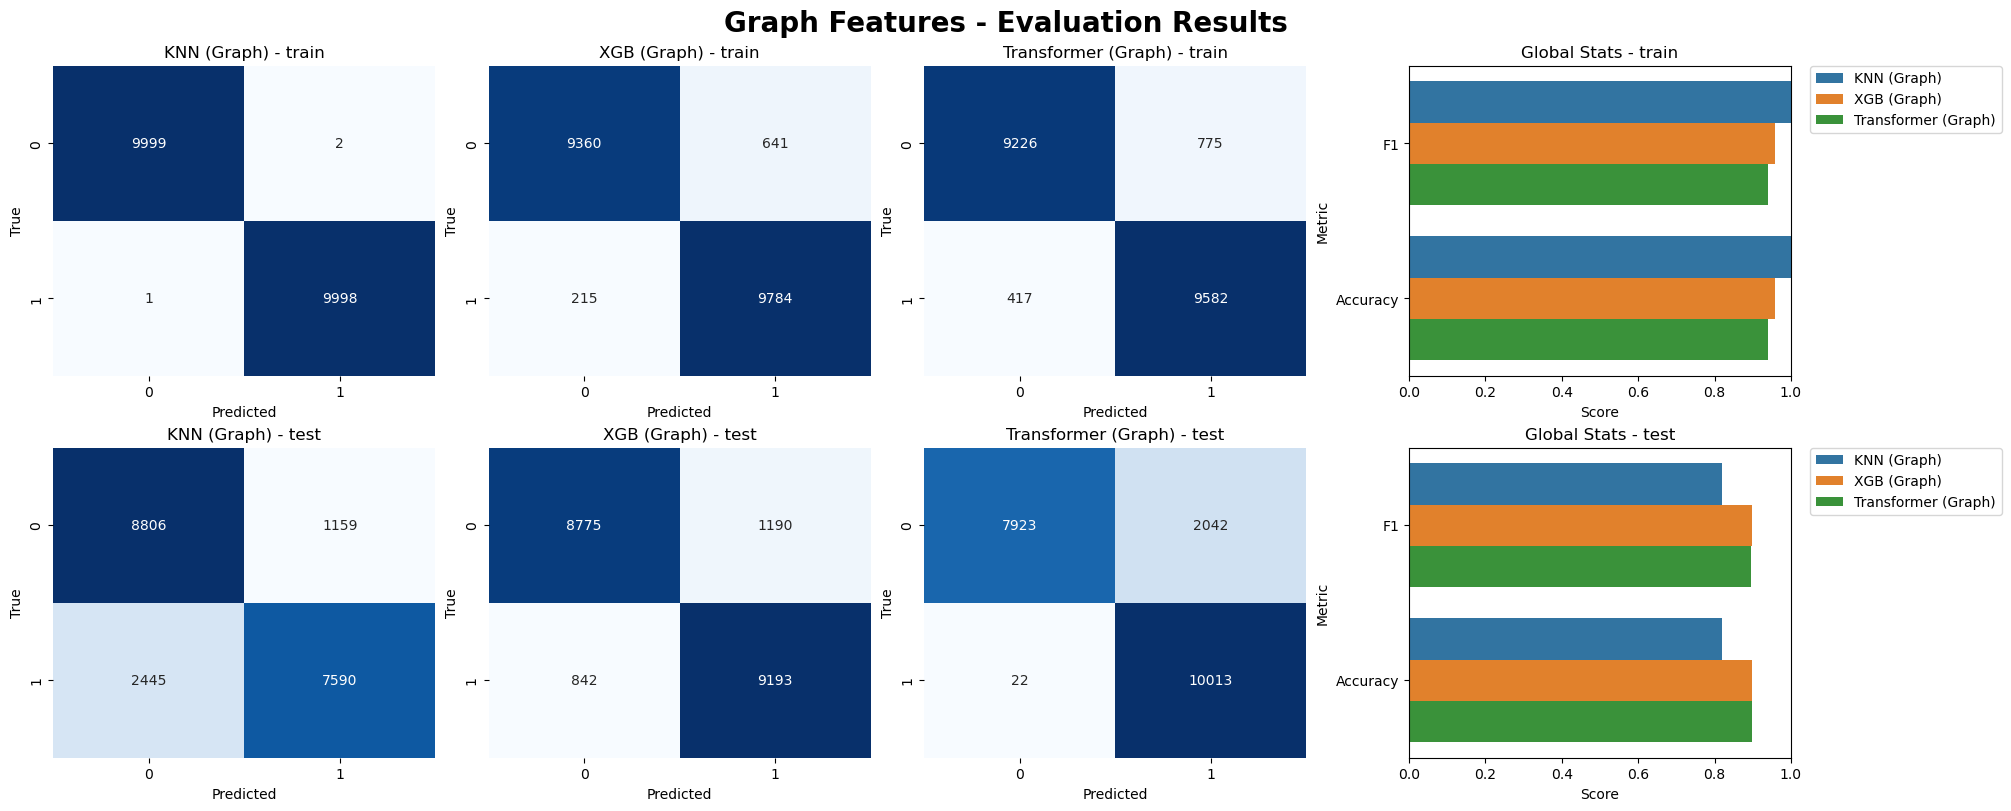

In [ ]:
sets_for_graph = set_dict(datasets=[graph_train, graph_test], names=['train', 'test'], id_columns=ID_COLUMNS)

graph_feat_models = [m for m in [graph_feat_knn, graph_feat_xgb, graph_feat_transformer] if m is not None]
graph_feat_names = []
if graph_feat_knn is not None:
    graph_feat_names.append('KNN (Graph)')
if graph_feat_xgb is not None:
    graph_feat_names.append('XGB (Graph)')
if graph_feat_transformer is not None:
    graph_feat_names.append('Transformer (Graph)')

if graph_feat_models:
    graph_feat_fig, graph_feat_metrics = plot_model_comparison(
        model_list=graph_feat_models,
        model_names=graph_feat_names,
        all_sets_list=[sets_for_graph] * len(graph_feat_models),
        title="Graph Features - Evaluation Results",
        figsize=(20, 8)
    )
    comparison_metrics['graph_features'] = graph_feat_metrics
    comparison_figure_paths['graph_features'] = save_show_close(graph_feat_fig, 'eval_models_graph.png', PATH_PLOTS, SAVE)
else:
    print("No models available for Graph Features")


### 2.3 Textual features

Textual 64 feature shapes: {'train': (2000, 128), 'test': (2000, 128)}


/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


predict:   0%|          | 0/4 [00:00<?, ?it/s]

predict:   0%|          | 0/4 [00:00<?, ?it/s]

Saved figure: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/report/src/eval_models_textual_64.png


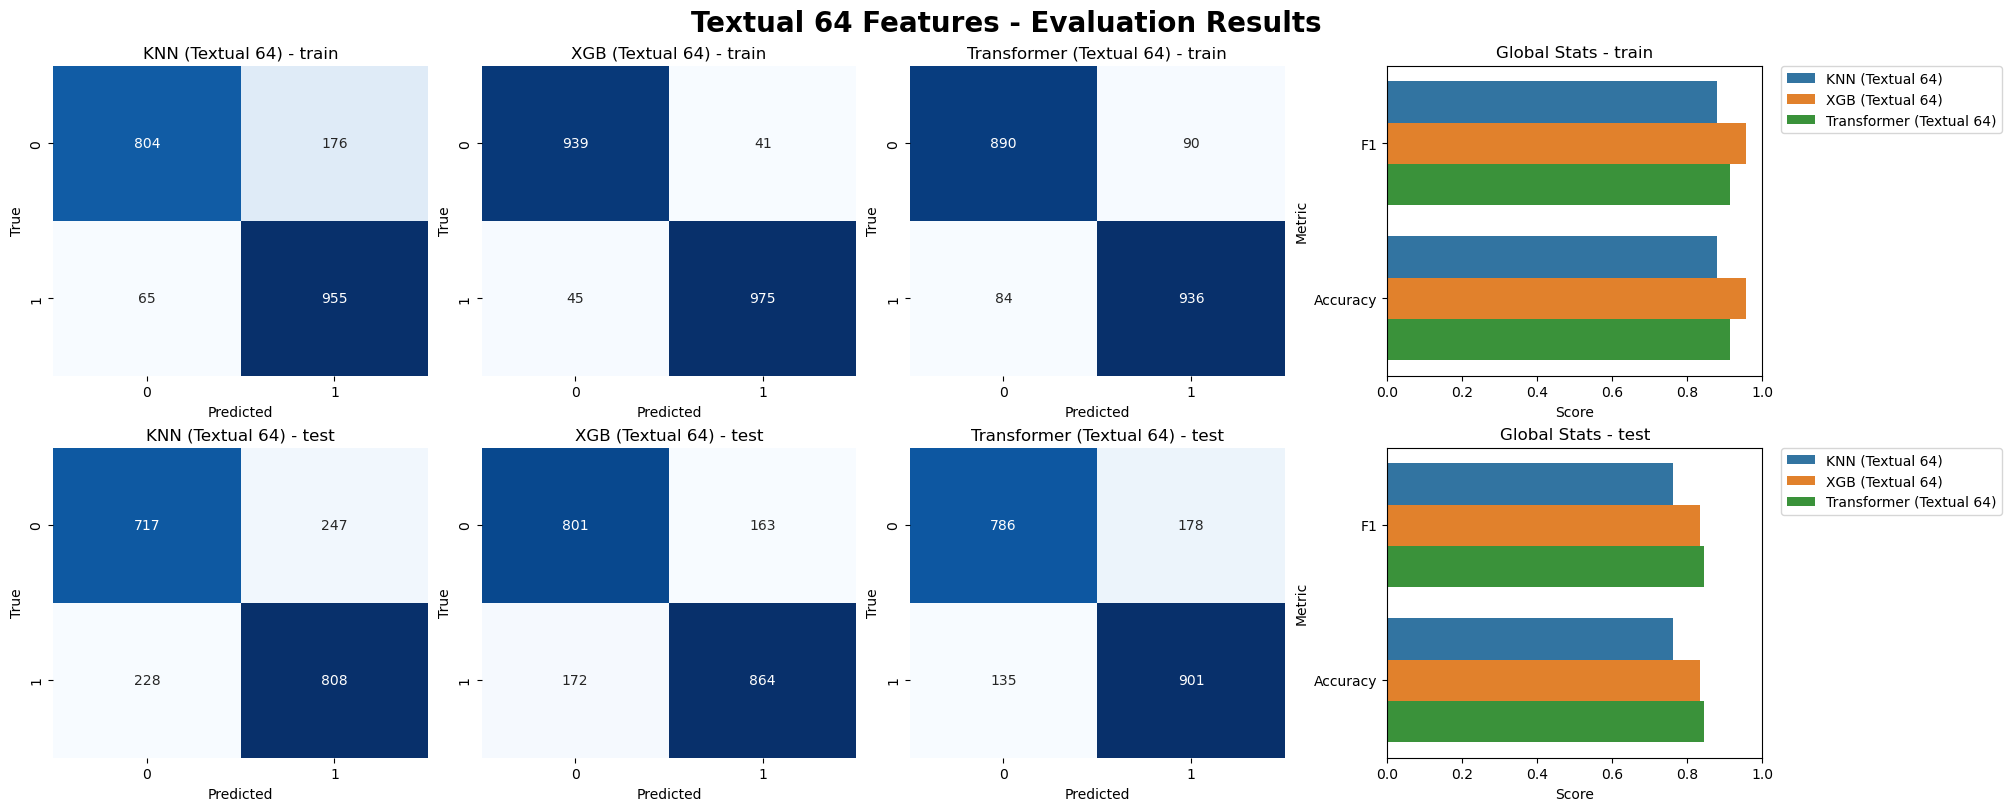

In [ ]:
sets_for_text64 = set_dict(datasets=[text64_train, text64_test], names=['train', 'test'], id_columns=ID_COLUMNS)
print("Textual 64 feature shapes:", {name: X.shape for name, (X, _) in sets_for_text64.items()})

text64_feat_models = [m for m in [text64_feat_knn, text64_feat_xgb, text64_feat_transformer] if m is not None]
text64_feat_names = []
if text64_feat_knn is not None:
    text64_feat_names.append('KNN (Textual 64)')
if text64_feat_xgb is not None:
    text64_feat_names.append('XGB (Textual 64)')
if text64_feat_transformer is not None:
    text64_feat_names.append('Transformer (Textual 64)')

if text64_feat_models:
    text64_feat_fig, text64_feat_metrics = plot_model_comparison(
        model_list=text64_feat_models,
        model_names=text64_feat_names,
        all_sets_list=[sets_for_text64] * len(text64_feat_models),
        title="Textual 64 Features - Evaluation Results",
        figsize=(20, 8)
    )
    comparison_metrics['textual_embeddings_64'] = text64_feat_metrics
    comparison_figure_paths['textual_embeddings_64'] = save_show_close(text64_feat_fig, 'eval_models_textual_64.png', PATH_PLOTS, SAVE)
else:
    print("No models available for Textual 64")


Textual 128 feature shapes: {'train': (2000, 256), 'test': (2000, 256)}


/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


predict:   0%|          | 0/4 [00:00<?, ?it/s]

predict:   0%|          | 0/4 [00:00<?, ?it/s]

Saved figure: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/report/src/eval_models_textual_128.png


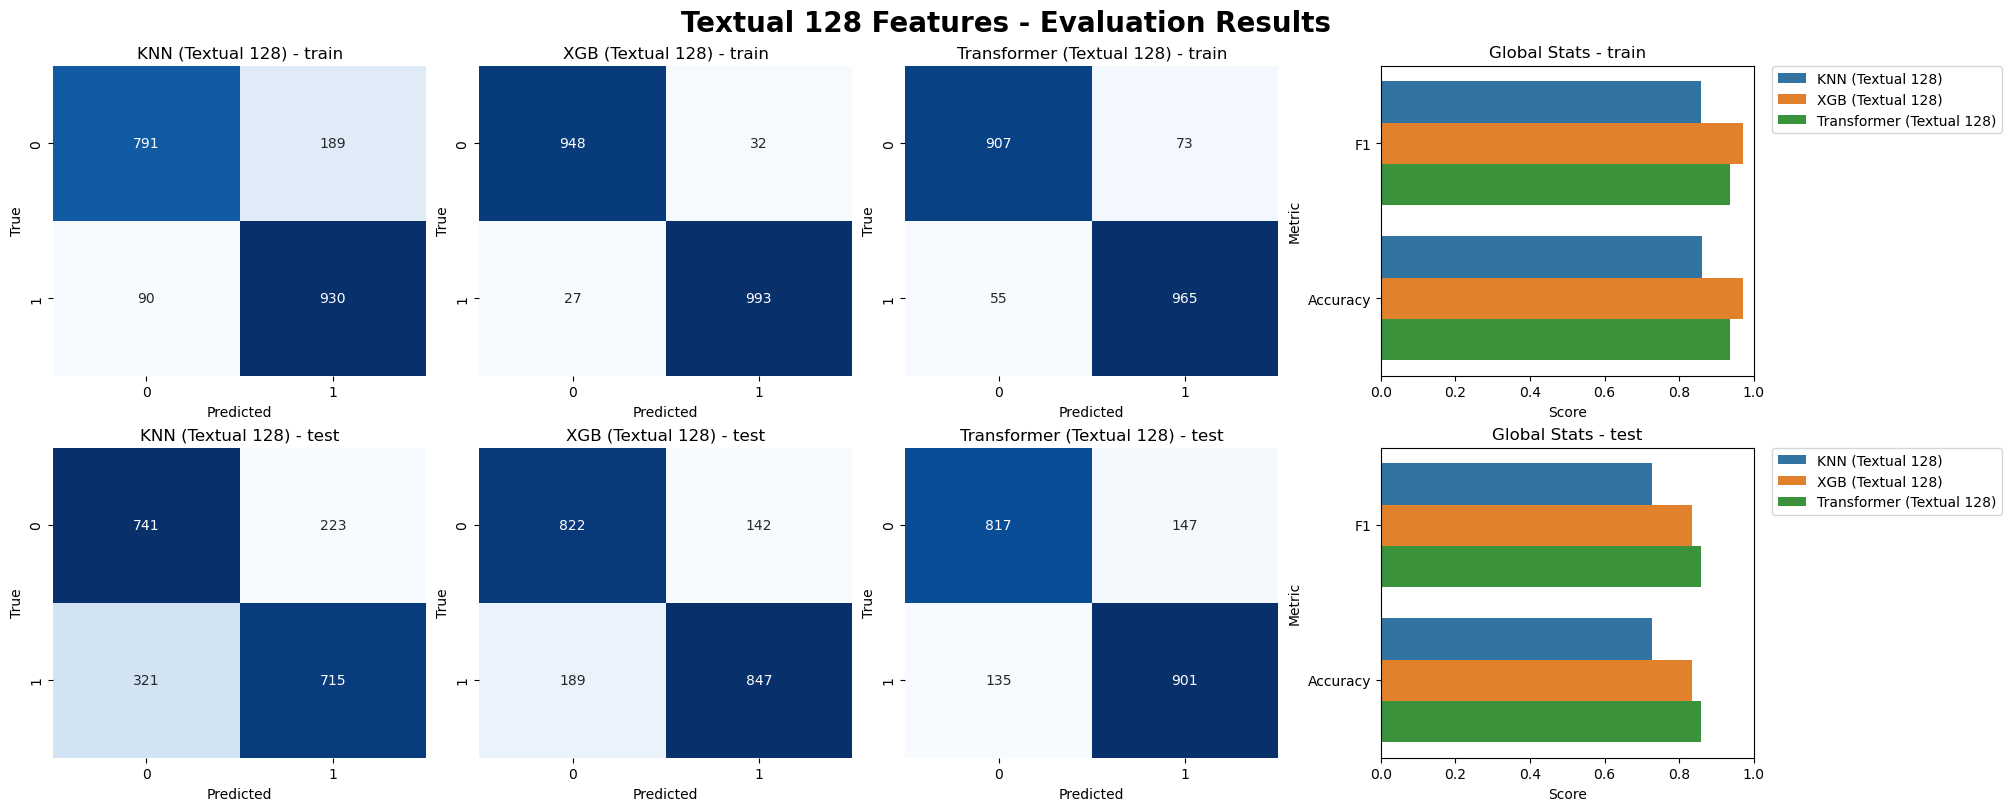

In [ ]:
sets_for_text128 = set_dict(datasets=[text128_train, text128_test], names=['train', 'test'], id_columns=ID_COLUMNS)
print("Textual 128 feature shapes:", {name: X.shape for name, (X, _) in sets_for_text128.items()})

text128_feat_models = [m for m in [text128_feat_knn, text128_feat_xgb, text128_feat_transformer] if m is not None]
text128_feat_names = []
if text128_feat_knn is not None:
    text128_feat_names.append('KNN (Textual 128)')
if text128_feat_xgb is not None:
    text128_feat_names.append('XGB (Textual 128)')
if text128_feat_transformer is not None:
    text128_feat_names.append('Transformer (Textual 128)')

if text128_feat_models:
    text128_feat_fig, text128_feat_metrics = plot_model_comparison(
        model_list=text128_feat_models,
        model_names=text128_feat_names,
        all_sets_list=[sets_for_text128] * len(text128_feat_models),
        title="Textual 128 Features - Evaluation Results",
        figsize=(20, 8)
    )
    comparison_metrics['textual_embeddings_128'] = text128_feat_metrics
    comparison_figure_paths['textual_embeddings_128'] = save_show_close(text128_feat_fig, 'eval_models_textual_128.png', PATH_PLOTS, SAVE)
else:
    print("No models available for Textual 128")


### 2.4 Combined features

/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


predict:   0%|          | 0/4 [00:00<?, ?it/s]

predict:   0%|          | 0/4 [00:00<?, ?it/s]

Saved figure: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/report/src/eval_models_combined.png


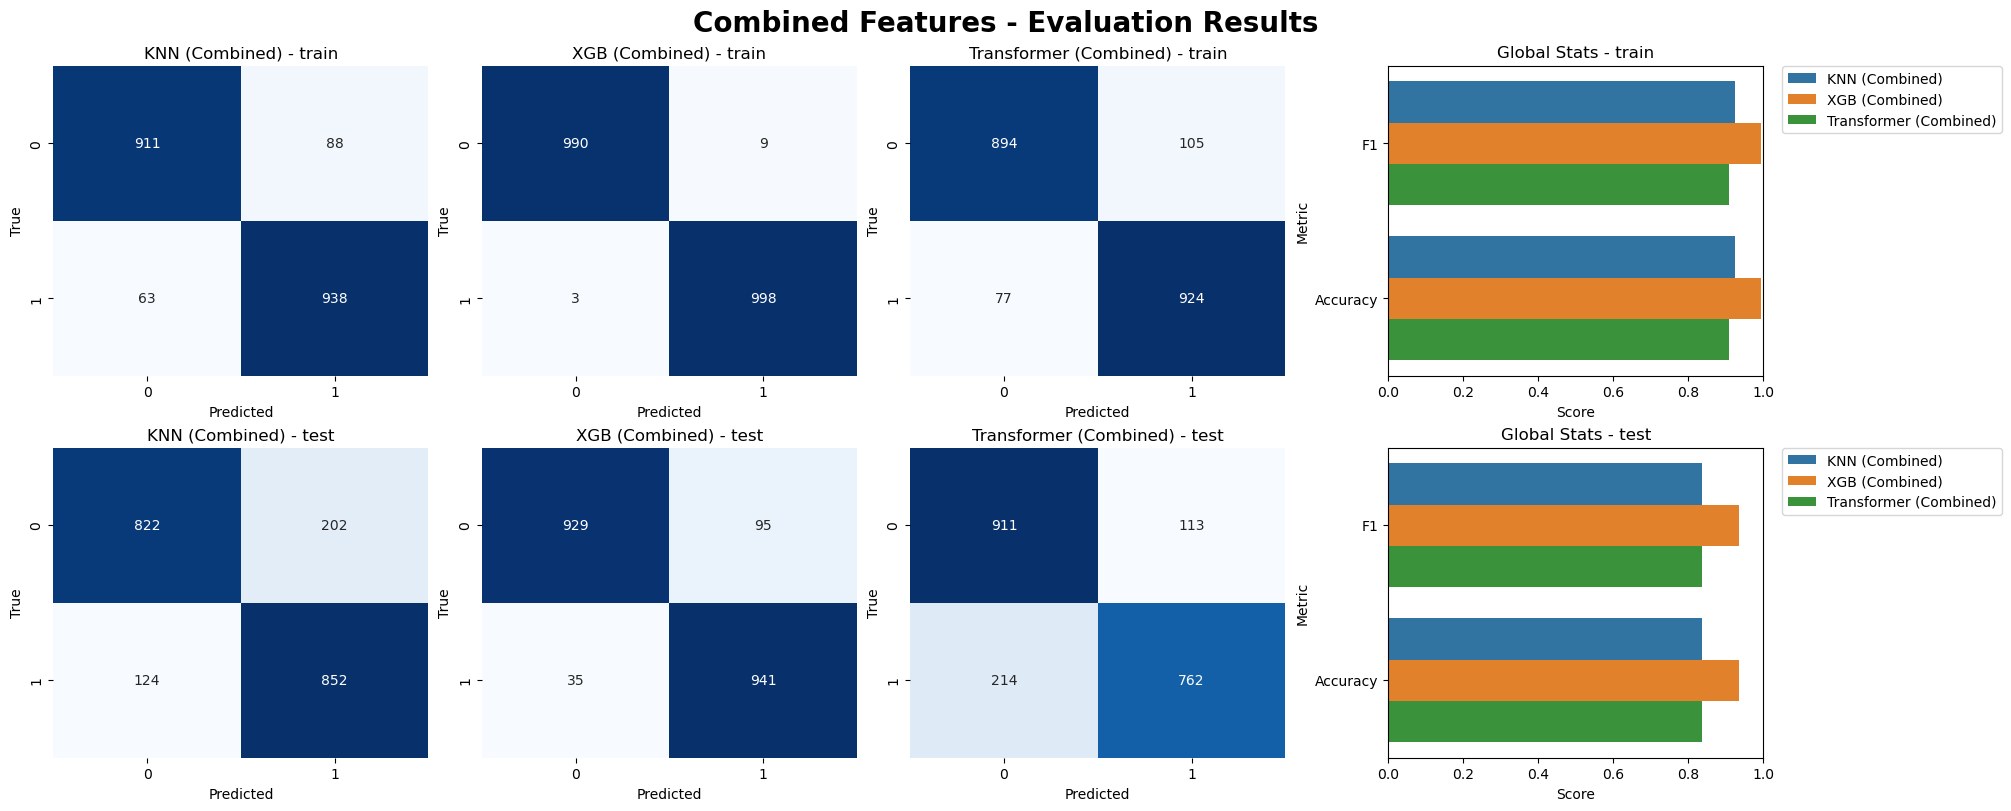

In [ ]:
sets_for_mix = set_dict(datasets=[mix_train, mix_test], names=['train', 'test'], id_columns=ID_COLUMNS)

mix_feat_models = [m for m in [all_feat_knn, all_feat_xgb, all_feat_transformer] if m is not None]
mix_feat_names = []
if all_feat_knn is not None:
    mix_feat_names.append('KNN (Combined)')
if all_feat_xgb is not None:
    mix_feat_names.append('XGB (Combined)')
if all_feat_transformer is not None:
    mix_feat_names.append('Transformer (Combined)')

if mix_feat_models:
    mix_feat_fig, mix_feat_metrics = plot_model_comparison(
        model_list=mix_feat_models,
        model_names=mix_feat_names,
        all_sets_list=[sets_for_mix] * len(mix_feat_models),
        title="Combined Features - Evaluation Results",
        figsize=(20, 8)
    )
    comparison_metrics['all_features'] = mix_feat_metrics
    comparison_figure_paths['all_features'] = save_show_close(mix_feat_fig, 'eval_models_combined.png', PATH_PLOTS, SAVE)
else:
    print("No models available for Combined Features")


## 3. Global Comparison

### 3.1 All figures

In [17]:
# Figures are saved during each comparison cell and then closed to keep RAM and notebook size under control.
pd.Series(comparison_figure_paths, name='saved_figure')


initial_features          /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_...
graph_features            /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_...
textual_embeddings_64     /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_...
textual_embeddings_128    /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_...
all_features              /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_...
Name: saved_figure, dtype: object

> TODO comments

### 3.2 Heatmap of the stats

In [ ]:
def plot_global_stats_heatmap(metrics_by_group, figsize=(8, 10)):
    """Collect test stats already computed by the plot cells and draw one global heatmap."""
    if not metrics_by_group:
        raise ValueError("No metrics available. Run the feature comparison cells first.")

    df_stats = pd.concat(metrics_by_group.values()).reset_index()
    df_stats = df_stats[df_stats['Set'] == 'test'].set_index('Model_Type')
    df_stats = df_stats[['F1', 'Accuracy', 'Precision', 'Recall']]

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(df_stats, annot=True, cmap='YlGnBu', fmt='.4f', cbar_kws={'label': 'Score'}, ax=ax)
    ax.set_title("Global Model Comparison - Test Set Metrics", fontsize=16, fontweight='bold')
    ax.set_ylabel("Model (Feature Set)")
    fig.tight_layout()

    comparison_figure_paths['global_stats_heatmap'] = save_show_close(fig, 'global_stats_heatmap.png', PATH_PLOTS, SAVE)
    return df_stats


Saved figure: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/report/src/global_stats_heatmap.png


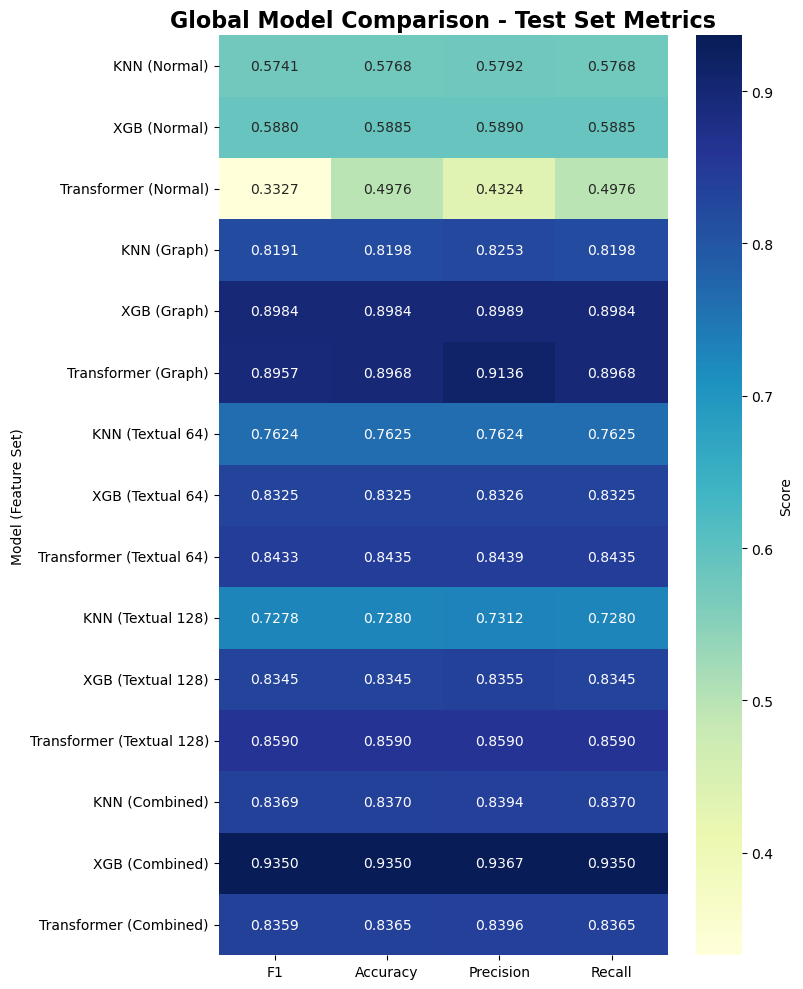

,F1,Accuracy,Precision,Recall
Model_Type,,,,
KNN (Normal),0.574106,0.57685,0.579224,0.57685
XGB (Normal),0.587969,0.58845,0.589013,0.58845
Transformer (Normal),0.332692,0.49760,0.432405,0.49760
KNN (Graph),0.819093,0.81980,0.825255,0.81980
XGB (Graph),0.898363,0.89840,0.898871,0.89840
Transformer (Graph),0.895699,0.89680,0.913629,0.89680
KNN (Textual 64),0.762397,0.76250,0.762432,0.76250
XGB (Textual 64),0.832524,0.83250,0.832581,0.83250
Transformer (Textual 64),0.843306,0.84350,0.843895,0.84350


In [19]:
global_test_metrics = plot_global_stats_heatmap(comparison_metrics)
global_test_metrics
